In [ ]:
!pip install librosa scikit-learn joblib

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/SnoringDataset/Snoring Dataset'

classes = ['0','1']

print(os.listdir(dataset_path))

['0', '1', 'Snoring_dataset.txt']


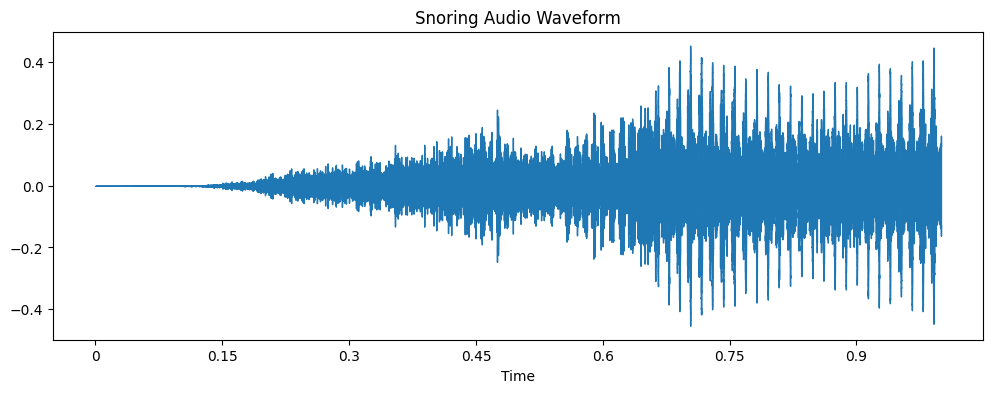

In [ ]:
sample = '/content/drive/MyDrive/SnoringDataset/Snoring Dataset/1/1_0.wav'

audio, sr = librosa.load(sample, sr=None)

plt.figure(figsize=(12,4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Snoring Audio Waveform")
plt.show()

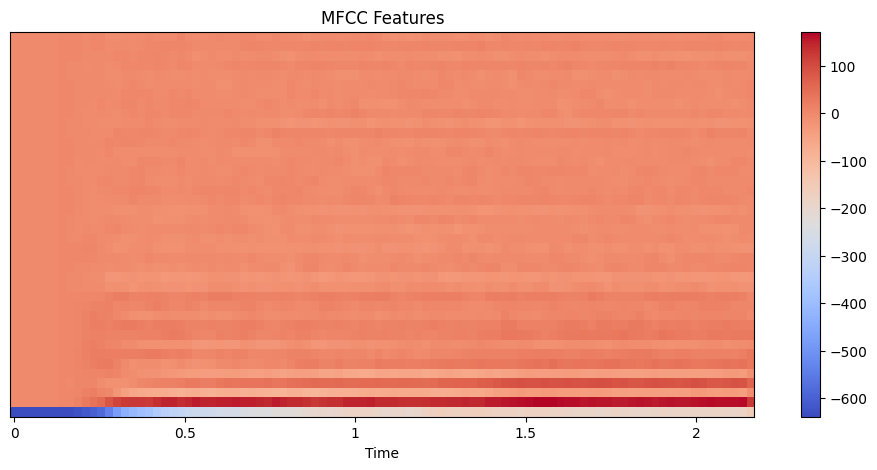

In [ ]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

plt.figure(figsize=(12,5))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")
plt.show()

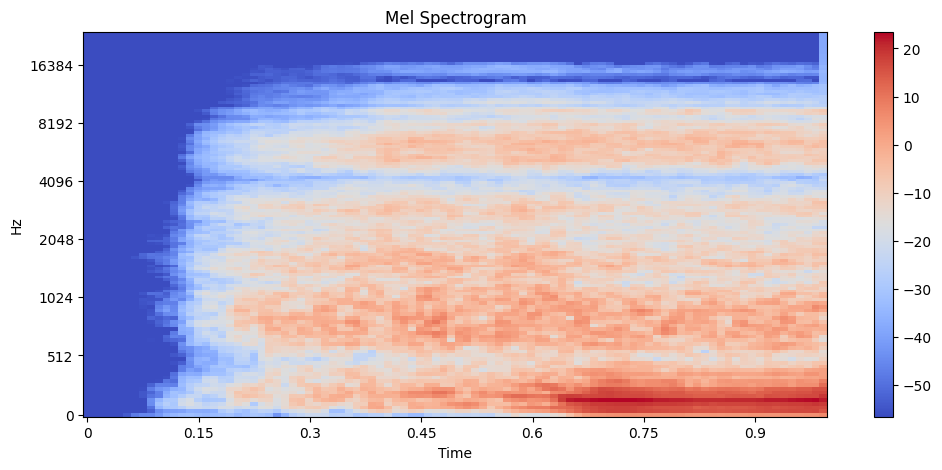

In [ ]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(12,5))
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

In [ ]:
def extract_features(file_path):

    try:
        audio, sample_rate = librosa.load(
            file_path,
            sr=None
        )

        mfccs = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=40
        )

        return np.mean(mfccs.T, axis=0)

    except Exception as e:
        print(file_path)
        print(e)
        return None

In [ ]:
X = []
Y = []

for label in classes:

    folder = os.path.join(dataset_path, label)

    print("Reading:", folder)

    for file in os.listdir(folder):

        if file.endswith(".wav"):

            path = os.path.join(folder, file)

            features = extract_features(path)

            if features is not None:

                X.append(features)
                Y.append(int(label))

X = np.array(X)
Y = np.array(Y)

print("Features:", X.shape)
print("Labels:", Y.shape)

Reading: /content/drive/MyDrive/SnoringDataset/Snoring Dataset/0
Reading: /content/drive/MyDrive/SnoringDataset/Snoring Dataset/1
Features: (1000, 40)
Labels: (1000,)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print(X_train.shape)
print(X_test.shape)

(800, 40)
(200, 40)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import time

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = []

for name, model in models.items():

    print("\n" + "="*50)
    print("Algorithm:", name)

    start = time.time()

    model.fit(X_train, Y_train)

    end = time.time()

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    cm = confusion_matrix(Y_test, Y_pred)

    results.append([
        name,
        accuracy*100,
        precision,
        recall,
        f1,
        end-start
    ])

    print("\nAccuracy :", accuracy*100)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(classification_report(
        Y_test,
        Y_pred,
        target_names=['Non-Snoring','Snoring']
    ))

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy (%)",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)"
    ]
)

print("\n")
print(results_df)


Algorithm: Decision Tree

Accuracy : 92.0
Precision: 0.92
Recall   : 0.92
F1 Score : 0.92

Confusion Matrix
[[92  8]
 [ 8 92]]

Classification Report
              precision    recall  f1-score   support

 Non-Snoring       0.92      0.92      0.92       100
     Snoring       0.92      0.92      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200


Algorithm: KNN

Accuracy : 97.0
Precision: 1.0
Recall   : 0.94
F1 Score : 0.9690721649484536

Confusion Matrix
[[100   0]
 [  6  94]]

Classification Report
              precision    recall  f1-score   support

 Non-Snoring       0.94      1.00      0.97       100
     Snoring       1.00      0.94      0.97       100

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200


Algorithm: SVM

Accuracy : 99.0
Prec

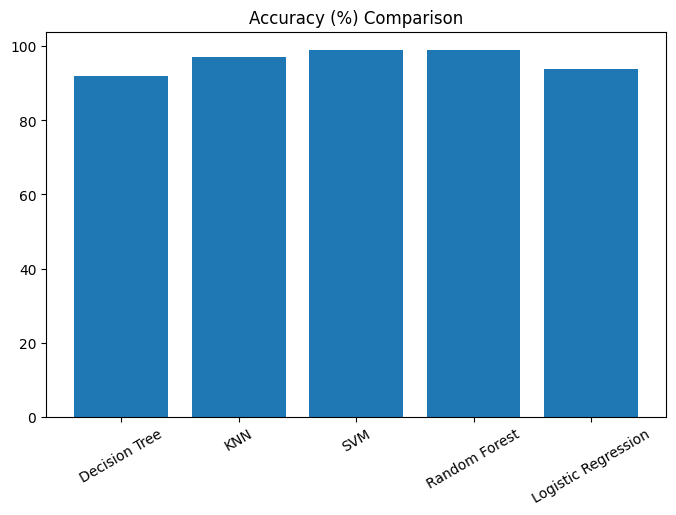

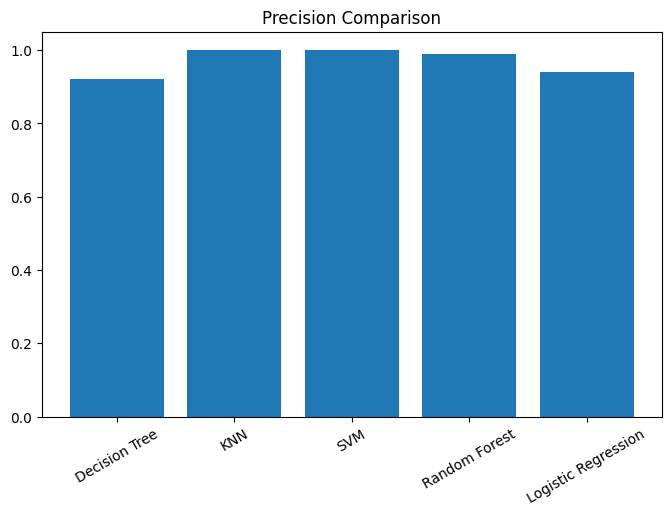

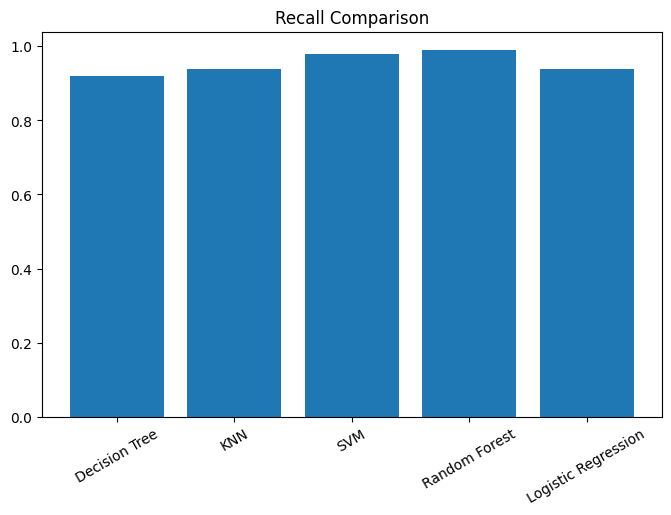

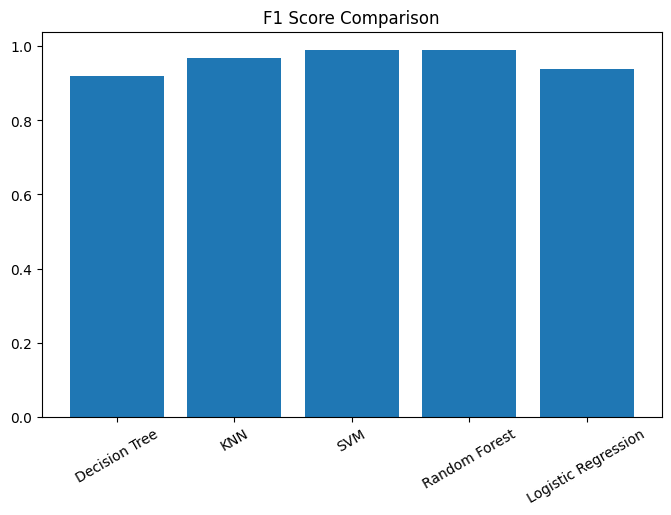

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy (%)", "Precision", "Recall", "F1 Score"]

for metric in metrics:

    plt.figure(figsize=(8,5))

    plt.bar(results_df["Algorithm"],
            results_df[metric])

    plt.title(metric + " Comparison")

    plt.xticks(rotation=30)

    plt.show()